# $(SASA) Models - Kmeans$

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pickle
import numpy as np
import pandas as pd

from pmbrl.model2 import Base_Line_Simple_Model
# from pmbrl.model2 import Model, Regularized_Reference_Loss
from pmbrl.data import Experiment_Data, get_data_expanded

In [2]:
data = Experiment_Data()

data.load(path='../training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1741,15,69,"(0.1433033517266329, 1.8075969481187537)","(-0.047, -0.186, 0.077, 0.177)",1,1.0,"(-0.051, -0.001, 0.081, 0.101)",0.0,1.0,"(-0.051, -0.187, 0.083, 0.191)"
1155,53,46,"(0.5759890361457483, 0.539204361971833)","(-0.279, 0.16, 0.118, -0.442)",1,1.0,"(-0.276, 0.358, 0.109, -0.8)",0.0,1.0,"(-0.269, 0.156, 0.093, -0.341)"
1028,10,42,"(0.0783299669233051, 0.1772545769968534)","(0.083, 0.007, -0.165, -0.272)",0,1.0,"(0.083, -0.204, -0.171, 0.384)",1.0,1.0,"(0.079, 0.02, -0.163, -0.564)"
685,73,23,"(0.2125978932043111, 0.6111562190979459)","(-0.914, -0.867, -0.068, -0.66)",1,1.0,"(-0.931, -0.672, -0.081, -0.939)",1.0,1.0,"(-0.945, -0.478, -0.1, -1.222)"
2332,19,92,"(0.1771043759930183, 0.8300521931250568)","(-0.147, -0.995, 0.111, 0.949)",0,1.0,"(-0.166, -1.186, 0.13, 1.156)",1.0,1.0,"(-0.19, -0.997, 0.153, 0.997)"
...,...,...,...,...,...,...,...,...,...,...
578,6,22,"(0.1859246409325834, 0.509421113235871)","(0.011, 0.366, -0.087, -0.695)",0,1.0,"(0.018, 0.171, -0.1, -0.418)",1.0,1.0,"(0.021, 0.368, -0.109, -0.756)"
1597,19,65,"(0.1785778102029531, 1.438381745613701)","(0.034, 0.192, -0.076, -0.204)",1,1.0,"(0.038, 0.379, -0.08, -0.32)",0.0,1.0,"(0.046, 0.192, -0.086, -0.222)"
1502,12,60,"(0.3937346446094771, 0.8373725854367047)","(0.018, 1.109, -0.097, -1.395)",1,1.0,"(0.04, 1.302, -0.125, -1.639)",1.0,1.0,"(0.066, 1.494, -0.158, -1.888)"
318,20,11,"(0.7542102482276688, 0.9476222740008828)","(0.017, 0.393, -0.086, -0.697)",1,1.0,"(0.025, 0.589, -0.099, -1.017)",0.0,1.0,"(0.037, 0.396, -0.12, -0.756)"


In [3]:
expansions = {
    's': ['s0', 's1', 's2', 's3'],
    's_': ['s_0', 's_1', 's_2', 's_3'],
    'p': ['p0', 'p1'],
}

df = get_data_expanded(data.build_training_dataset(), expansions)
# df = df.loc[df['episode']<15].copy()
df

,step,episode,p,s,a,r,s_,a_,r_,s__,s0,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1
762,7,27,"(0.3197179553472873, 0.8108021737171857)","(0.021, 0.176, -0.048, -0.29)",1,1.0,"(0.025, 0.368, -0.054, -0.516)",1.0,1.0,"(0.032, 0.56, -0.064, -0.743)",0.021,0.176,-0.048,-0.290,0.025,0.368,-0.054,-0.516,0.319718,0.810802
1794,11,70,"(0.6624936831395084, 0.7113031322267719)","(-0.098, -0.578, 0.157, 1.264)",0,1.0,"(-0.11, -0.777, 0.183, 1.659)",0.0,1.0,"(-0.125, -0.976, 0.216, 2.06)",-0.098,-0.578,0.157,1.264,-0.110,-0.777,0.183,1.659,0.662494,0.711303
2088,45,81,"(0.1825292152212203, 0.91730535067745)","(0.185, 0.139, 0.063, 0.324)",1,1.0,"(0.188, 0.328, 0.07, 0.166)",1.0,1.0,"(0.194, 0.517, 0.073, 0.009)",0.185,0.139,0.063,0.324,0.188,0.328,0.070,0.166,0.182529,0.917305
929,14,38,"(0.4545373771214862, 0.5810082803318615)","(-0.021, 0.359, 0.068, -0.436)",1,1.0,"(-0.014, 0.555, 0.059, -0.75)",1.0,1.0,"(-0.003, 0.751, 0.044, -1.067)",-0.021,0.359,0.068,-0.436,-0.014,0.555,0.059,-0.750,0.454537,0.581008
161,45,6,"(0.2451557536988955, 1.3793967951445396)","(-0.016, -0.197, -0.06, -0.027)",0,1.0,"(-0.02, -0.384, -0.061, 0.083)",1.0,1.0,"(-0.028, -0.196, -0.059, -0.043)",-0.016,-0.197,-0.060,-0.027,-0.020,-0.384,-0.061,0.083,0.245156,1.379397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1937,18,77,"(0.1064004661572971, 0.3173964772630564)","(0.007, -0.37, -0.067, 0.224)",0,1.0,"(-0.001, -0.571, -0.062, 0.652)",1.0,1.0,"(-0.012, -0.367, -0.049, 0.159)",0.007,-0.370,-0.067,0.224,-0.001,-0.571,-0.062,0.652,0.106400,0.317396
2023,17,80,"(0.077800491974935, 0.5006250071926374)","(-0.007, 0.151, -0.042, -0.367)",0,1.0,"(-0.004, -0.044, -0.049, -0.093)",0.0,1.0,"(-0.005, -0.238, -0.051, 0.179)",-0.007,0.151,-0.042,-0.367,-0.004,-0.044,-0.049,-0.093,0.077800,0.500625
1561,15,64,"(0.3183694304142259, 0.9452629977131142)","(0.065, -0.177, -0.096, -0.071)",0,1.0,"(0.062, -0.366, -0.097, 0.093)",1.0,1.0,"(0.054, -0.175, -0.095, -0.109)",0.065,-0.177,-0.096,-0.071,0.062,-0.366,-0.097,0.093,0.318369,0.945263
1837,6,73,"(0.1621684058210441, 0.4843613270065507)","(-0.015, -0.41, -0.001, 0.638)",0,1.0,"(-0.023, -0.606, 0.012, 0.954)",1.0,1.0,"(-0.035, -0.41, 0.031, 0.642)",-0.015,-0.410,-0.001,0.638,-0.023,-0.606,0.012,0.954,0.162168,0.484361


# Initialization by Random Partitioning

In [4]:
k = 5
models = [Base_Line_Simple_Model() for _ in range(k)]

In [5]:
groups = np.random.randint(low=0, high=k, size=df.episode.unique().shape[0])
df['group'] = np.nan

for i, g in enumerate(groups):
    df.loc[df['episode']==i,'group'] = g
df

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1,group
762,7,27,"(0.3197179553472873, 0.8108021737171857)","(0.021, 0.176, -0.048, -0.29)",1,1.0,"(0.025, 0.368, -0.054, -0.516)",1.0,1.0,"(0.032, 0.56, -0.064, -0.743)",...,0.176,-0.048,-0.290,0.025,0.368,-0.054,-0.516,0.319718,0.810802,4.0
1794,11,70,"(0.6624936831395084, 0.7113031322267719)","(-0.098, -0.578, 0.157, 1.264)",0,1.0,"(-0.11, -0.777, 0.183, 1.659)",0.0,1.0,"(-0.125, -0.976, 0.216, 2.06)",...,-0.578,0.157,1.264,-0.110,-0.777,0.183,1.659,0.662494,0.711303,3.0
2088,45,81,"(0.1825292152212203, 0.91730535067745)","(0.185, 0.139, 0.063, 0.324)",1,1.0,"(0.188, 0.328, 0.07, 0.166)",1.0,1.0,"(0.194, 0.517, 0.073, 0.009)",...,0.139,0.063,0.324,0.188,0.328,0.070,0.166,0.182529,0.917305,0.0
929,14,38,"(0.4545373771214862, 0.5810082803318615)","(-0.021, 0.359, 0.068, -0.436)",1,1.0,"(-0.014, 0.555, 0.059, -0.75)",1.0,1.0,"(-0.003, 0.751, 0.044, -1.067)",...,0.359,0.068,-0.436,-0.014,0.555,0.059,-0.750,0.454537,0.581008,0.0
161,45,6,"(0.2451557536988955, 1.3793967951445396)","(-0.016, -0.197, -0.06, -0.027)",0,1.0,"(-0.02, -0.384, -0.061, 0.083)",1.0,1.0,"(-0.028, -0.196, -0.059, -0.043)",...,-0.197,-0.060,-0.027,-0.020,-0.384,-0.061,0.083,0.245156,1.379397,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1937,18,77,"(0.1064004661572971, 0.3173964772630564)","(0.007, -0.37, -0.067, 0.224)",0,1.0,"(-0.001, -0.571, -0.062, 0.652)",1.0,1.0,"(-0.012, -0.367, -0.049, 0.159)",...,-0.370,-0.067,0.224,-0.001,-0.571,-0.062,0.652,0.106400,0.317396,1.0
2023,17,80,"(0.077800491974935, 0.5006250071926374)","(-0.007, 0.151, -0.042, -0.367)",0,1.0,"(-0.004, -0.044, -0.049, -0.093)",0.0,1.0,"(-0.005, -0.238, -0.051, 0.179)",...,0.151,-0.042,-0.367,-0.004,-0.044,-0.049,-0.093,0.077800,0.500625,0.0
1561,15,64,"(0.3183694304142259, 0.9452629977131142)","(0.065, -0.177, -0.096, -0.071)",0,1.0,"(0.062, -0.366, -0.097, 0.093)",1.0,1.0,"(0.054, -0.175, -0.095, -0.109)",...,-0.177,-0.096,-0.071,0.062,-0.366,-0.097,0.093,0.318369,0.945263,3.0
1837,6,73,"(0.1621684058210441, 0.4843613270065507)","(-0.015, -0.41, -0.001, 0.638)",0,1.0,"(-0.023, -0.606, 0.012, 0.954)",1.0,1.0,"(-0.035, -0.41, 0.031, 0.642)",...,-0.410,-0.001,0.638,-0.023,-0.606,0.012,0.954,0.162168,0.484361,3.0


## Initial Training 

In [6]:
def train_models(models, train_dataset):
    train_data = [None for _ in models]

    for g, model in enumerate(models):
        # print('train model: ', g)
        group_data = train_dataset.loc[train_dataset['group']==g]
        x, y = model.get_features_targets(group_data)
        trainer = model.train(x, y, num_epochs=5000)
        train_data[g] = data.get_training_data(trainer, inference_schema=model.inference_schema)
    
    return train_data


In [7]:
train_data = train_models(models, df[[
    's', 's_', 's__', 'a', 'a_', 'r', 'p', 'group'
]])

train_data[0].head()

,epoch,mse_s,transition,reward
0,0,"[0.0362820103764534, 0.2912842929363251, 0.162...",1.665712,1.517627
1,1,"[0.034906040877103806, 0.28877565264701843, 0....",1.651241,1.511798
2,2,"[0.0335705541074276, 0.28627070784568787, 0.15...",1.636865,1.506040
3,3,"[0.03227618709206581, 0.28376686573028564, 0.1...",1.622585,1.500351
4,4,"[0.031023254618048668, 0.281263530254364, 0.15...",1.608401,1.494734


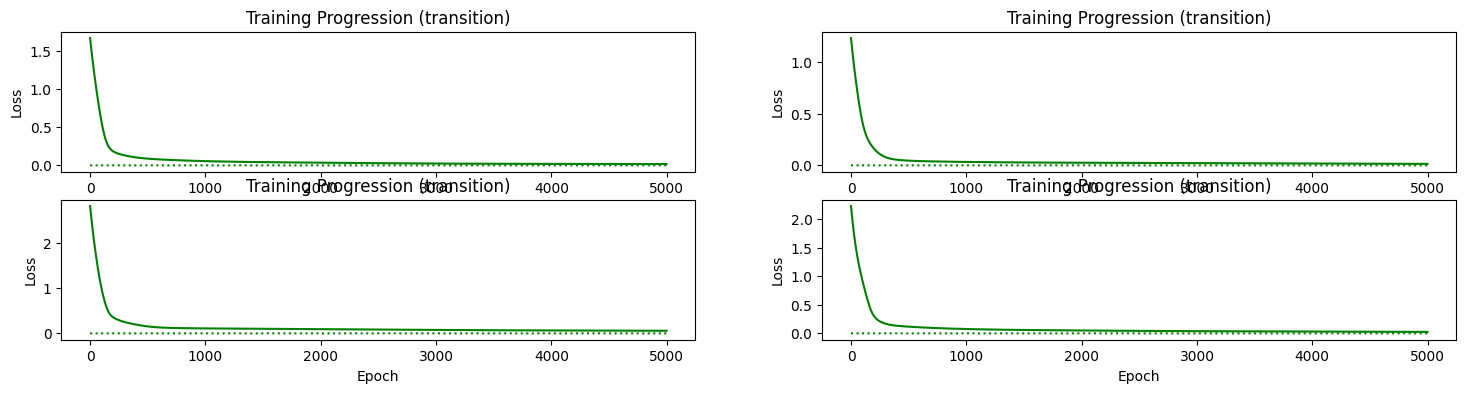

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(18, 4))

data.plot_training_loss(axs[0][0], train_data[0].transition)
data.plot_training_loss(axs[0][1], train_data[1].transition)
data.plot_training_loss(axs[1][0], train_data[2].transition)
data.plot_training_loss(axs[1][1], train_data[3].transition)

plt.show()

# Predict 

In [9]:
def evaluate(models, df):
    def predict(model):
        prediction_dataset = df.copy()
        prediction_dataset[model.grouped_targets_lables] = prediction_dataset.apply(lambda row: data._predict_from_row(row, model), axis=1, result_type='expand')
        return prediction_dataset

    predictions = [predict(m) for m in models]

    prediction_dataset = df.copy()
    for i, pred in enumerate(predictions):
        prediction_dataset[f'estimated_s_model_{i}'] = pred['estimated_s']
        
        results = data.get_evaluation_metrics(pred, p=False)
        prediction_dataset[f'rse_model_{i}'] = results['rse']
        prediction_dataset[f'rse_normalized_model_{i}'] = results['rse_normalized']

        prediction_dataset[f'rse_s0_model_{i}'] = results['rse_s0']
        prediction_dataset[f'rse_s1_model_{i}'] = results['rse_s1']
        prediction_dataset[f'rse_s2_model_{i}'] = results['rse_s2']
        prediction_dataset[f'rse_s3_model_{i}'] = results['rse_s3']

        prediction_dataset[f'rse_s0_normalized_model_{i}'] = results['rse_s0_normalized']
        prediction_dataset[f'rse_s1_normalized_model_{i}'] = results['rse_s1_normalized']
        prediction_dataset[f'rse_s2_normalized_model_{i}'] = results['rse_s2_normalized']
        prediction_dataset[f'rse_s3_normalized_model_{i}'] = results['rse_s3_normalized']


    return prediction_dataset

In [10]:
prediction_dataset = evaluate(models, df)
prediction_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_model_4,rse_normalized_model_4,rse_s0_model_4,rse_s1_model_4,rse_s2_model_4,rse_s3_model_4,rse_s0_normalized_model_4,rse_s1_normalized_model_4,rse_s2_normalized_model_4,rse_s3_normalized_model_4
762,7,27,"(0.3197179553472873, 0.8108021737171857)","(0.021, 0.176, -0.048, -0.29)",1,1.0,"(0.025, 0.368, -0.054, -0.516)",1.0,1.0,"(0.032, 0.56, -0.064, -0.743)",...,0.119,0.477755,0.004,0.007,0.003,0.105,0.405079,0.420282,0.505995,0.579661
1794,11,70,"(0.6624936831395084, 0.7113031322267719)","(-0.098, -0.578, 0.157, 1.264)",0,1.0,"(-0.11, -0.777, 0.183, 1.659)",0.0,1.0,"(-0.125, -0.976, 0.216, 2.06)",...,0.052,0.480909,0.003,0.033,0.009,0.007,0.404663,0.424813,0.520384,0.573778
2088,45,81,"(0.1825292152212203, 0.91730535067745)","(0.185, 0.139, 0.063, 0.324)",1,1.0,"(0.188, 0.328, 0.07, 0.166)",1.0,1.0,"(0.194, 0.517, 0.073, 0.009)",...,0.265,0.483759,0.022,0.023,0.006,0.214,0.412573,0.423070,0.513189,0.586205
929,14,38,"(0.4545373771214862, 0.5810082803318615)","(-0.021, 0.359, 0.068, -0.436)",1,1.0,"(-0.014, 0.555, 0.059, -0.75)",1.0,1.0,"(-0.003, 0.751, 0.044, -1.067)",...,0.068,0.479445,0.017,0.032,0.004,0.015,0.410491,0.424638,0.508393,0.574259
161,45,6,"(0.2451557536988955, 1.3793967951445396)","(-0.016, -0.197, -0.06, -0.027)",0,1.0,"(-0.02, -0.384, -0.061, 0.083)",1.0,1.0,"(-0.028, -0.196, -0.059, -0.043)",...,0.252,0.484762,0.002,0.025,0.011,0.214,0.404246,0.423419,0.525180,0.586205


In [11]:
def reagroup(prediction_dataset):
    agg_results = prediction_dataset[['episode'] + [
    f'rse_model_{i}' for i,_ in enumerate(models)
    #     'rse_model_0',
    #     'rse_model_1',
    #     'rse_model_2',
    #     'rse_model_3',
    #     'rse_model_4',
    ]].groupby('episode').mean().reset_index()

    agg_results['best_model'] = agg_results.apply(lambda row: np.argmin(row[1:].values), axis=1)
    print(agg_results['best_model'].value_counts())

    prediction_dataset['best_model'] = prediction_dataset.apply(lambda row: agg_results[agg_results['episode']==row['episode']].best_model.values[0],axis=1)
    prediction_dataset['best_rse'] = prediction_dataset.apply(lambda row: row[f'rse_model_{row.best_model}'],axis=1)

    return prediction_dataset

In [12]:
prediction_dataset = reagroup(prediction_dataset)
prediction_dataset[['best_rse']].describe()

best_model
0    32
4    22
1    18
3    15
2    13
Name: count, dtype: int64


,best_rse
count,2504.000000
mean,0.116944
std,0.127210
min,0.007000
25%,0.052000
50%,0.090000
75%,0.144000
max,2.067000


# LOOP

In [13]:

# while True: 
for _ in range(10): 
    check = prediction_dataset[prediction_dataset['group'] != prediction_dataset['best_model']].shape[0]
    print(f'epis_changed: {check}')
    if check == 0:
        break
    

    train_df = prediction_dataset[['s', 's_', 's__', 'a', 'a_', 'r', 'p']].copy()
    train_df['group'] = prediction_dataset['best_model']
    train_data = train_models(models, train_df)

    prediction_dataset = evaluate(models, prediction_dataset)

    prediction_dataset = reagroup(prediction_dataset)
    print(prediction_dataset[['best_rse']].mean())
    

epis_changed: 1132
best_model
3    26
1    23
0    23
4    19
2     9
Name: count, dtype: int64
best_rse    0.066951
dtype: float64
epis_changed: 1454
best_model
3    29
1    26
4    21
0    16
2     8
Name: count, dtype: int64
best_rse    0.04866
dtype: float64
epis_changed: 1581
best_model
1    29
3    29
4    22
0    13
2     7
Name: count, dtype: int64
best_rse    0.04117
dtype: float64
epis_changed: 1632
best_model
1    29
3    29
4    23
0    13
2     6
Name: count, dtype: int64
best_rse    0.037493
dtype: float64
epis_changed: 1631
best_model
1    29
3    29
4    23
0    13
2     6
Name: count, dtype: int64
best_rse    0.035519
dtype: float64
epis_changed: 1631
best_model
1    29
3    29
4    23
0    13
2     6
Name: count, dtype: int64
best_rse    0.034818
dtype: float64
epis_changed: 1631
best_model
1    29
3    29
4    23
0    13
2     6
Name: count, dtype: int64
best_rse    0.034405
dtype: float64
epis_changed: 1631
best_model
1    29
3    29
4    23
0    13
2     6
Name: co

# Export Model 

In [14]:
import pickle

exp = {
    "data": prediction_dataset,
    "model": models 
}

nome_do_arquivo = 'kmodels.pkl'
with open(nome_do_arquivo, 'wb') as arquivo:
    pickle.dump(exp, arquivo)